In [1]:
import pandas as pd
import numpy as np
import re
import streamlit as st
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [11]:
df = pd.read_csv("Dataset_task_9.csv", sep=';',decimal=',')

In [12]:
df.head()

,transaction_id,account_id,transaction_date,transaction_time,transaction_amount_eur,transaction_type,location,device_type,merchant_category,transactions_last_24h,avg_account_transaction_eur,account_age_months,fraud_status
0,TXN-00001,ACC-0082,2026-03-09,10:38,"480,89",Card Purchase,Barcelona,POS Terminal,Retail,1,249.88,48,Legitimate
1,TXN-00002,ACC-0101,2026-01-24,21:50,"193,66",Bank Transfer,Barcelona,Mobile,Electronics,1,274.92,2,Legitimate
2,TXN-00003,ACC-0117,2026-03-26,22:38,"209,02",Online Payment,Berlin,Mobile,Electronics,5,422.07,61,Legitimate
3,TXN-00004,ACC-0147,2026-01-03,21:29,"162,66",Bank Transfer,Berlin,Mobile,Food,5,217.66,129,Legitimate
4,TXN-00005,ACC-0058,2026-02-13,16:33,"333,93",Card Purchase,Madrid,POS Terminal,Entertainment,1,204.98,67,Legitimate


In [13]:
df.dtypes

transaction_id                     str
account_id                         str
transaction_date                   str
transaction_time                   str
transaction_amount_eur             str
transaction_type                   str
location                           str
device_type                        str
merchant_category                  str
transactions_last_24h            int64
avg_account_transaction_eur    float64
account_age_months               int64
fraud_status                       str
dtype: object

In [14]:
isnull_count = df.isnull().sum()
print("Number of Nulls:", isnull_count)

# Total Nulls in Dataset
Total_isnull_count = isnull_count.sum()

print("Total Nulls:", Total_isnull_count)

Number of Nulls: transaction_id                 0
account_id                     0
transaction_date               0
transaction_time               0
transaction_amount_eur         0
transaction_type               0
location                       0
device_type                    0
merchant_category              0
transactions_last_24h          0
avg_account_transaction_eur    0
account_age_months             0
fraud_status                   0
dtype: int64
Total Nulls: 0


In [15]:
# convert numeric-looking strings to floats
import numbers

def parse_number(value):
    if pd.isna(value):
        return np.nan

    # Already numeric: do not treat "." as a thousands separator
    if isinstance(value, numbers.Number):
        return float(value)


    # Handle separators based on their presence
    if "," in value and "." in value:
        # Example: 1.234,56 -> 1234.56
        value = value.replace(".", "").replace(",", ".")
    elif "," in value:
        # Example: 1234,56 -> 1234.56
        value = value.replace(",", ".")
    # If only "." exists, assume it is already a decimal point

    return pd.to_numeric(value, errors="coerce")


cols = [
    "transaction_amount_eur",
    "avg_account_transaction_eur",
]

for col in cols:
    df[col] = df[col].map(parse_number)

In [16]:
df.head()

,transaction_id,account_id,transaction_date,transaction_time,transaction_amount_eur,transaction_type,location,device_type,merchant_category,transactions_last_24h,avg_account_transaction_eur,account_age_months,fraud_status
0,TXN-00001,ACC-0082,2026-03-09,10:38,480.89,Card Purchase,Barcelona,POS Terminal,Retail,1,249.88,48,Legitimate
1,TXN-00002,ACC-0101,2026-01-24,21:50,193.66,Bank Transfer,Barcelona,Mobile,Electronics,1,274.92,2,Legitimate
2,TXN-00003,ACC-0117,2026-03-26,22:38,209.02,Online Payment,Berlin,Mobile,Electronics,5,422.07,61,Legitimate
3,TXN-00004,ACC-0147,2026-01-03,21:29,162.66,Bank Transfer,Berlin,Mobile,Food,5,217.66,129,Legitimate
4,TXN-00005,ACC-0058,2026-02-13,16:33,333.93,Card Purchase,Madrid,POS Terminal,Entertainment,1,204.98,67,Legitimate


In [17]:
df.dtypes

transaction_id                     str
account_id                         str
transaction_date                   str
transaction_time                   str
transaction_amount_eur         float64
transaction_type                   str
location                           str
device_type                        str
merchant_category                  str
transactions_last_24h            int64
avg_account_transaction_eur    float64
account_age_months               int64
fraud_status                       str
dtype: object

In [18]:
# Parse date
df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="%Y-%m-%d", errors="coerce")

# Parse time as timedelta
df["transaction_time"] = pd.to_timedelta(df["transaction_time"] + ":00", errors="coerce")



In [19]:
df.head()

,transaction_id,account_id,transaction_date,transaction_time,transaction_amount_eur,transaction_type,location,device_type,merchant_category,transactions_last_24h,avg_account_transaction_eur,account_age_months,fraud_status
0,TXN-00001,ACC-0082,2026-03-09,0 days 10:38:00,480.89,Card Purchase,Barcelona,POS Terminal,Retail,1,249.88,48,Legitimate
1,TXN-00002,ACC-0101,2026-01-24,0 days 21:50:00,193.66,Bank Transfer,Barcelona,Mobile,Electronics,1,274.92,2,Legitimate
2,TXN-00003,ACC-0117,2026-03-26,0 days 22:38:00,209.02,Online Payment,Berlin,Mobile,Electronics,5,422.07,61,Legitimate
3,TXN-00004,ACC-0147,2026-01-03,0 days 21:29:00,162.66,Bank Transfer,Berlin,Mobile,Food,5,217.66,129,Legitimate
4,TXN-00005,ACC-0058,2026-02-13,0 days 16:33:00,333.93,Card Purchase,Madrid,POS Terminal,Entertainment,1,204.98,67,Legitimate


In [20]:
df.dtypes

transaction_id                             str
account_id                                 str
transaction_date                datetime64[us]
transaction_time               timedelta64[us]
transaction_amount_eur                 float64
transaction_type                           str
location                                   str
device_type                                str
merchant_category                          str
transactions_last_24h                    int64
avg_account_transaction_eur            float64
account_age_months                       int64
fraud_status                               str
dtype: object

In [21]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [transaction_id, account_id, transaction_date, transaction_time, transaction_amount_eur, transaction_type, location, device_type, merchant_category, transactions_last_24h, avg_account_transaction_eur, account_age_months, fraud_status]
Index: []


In [25]:
# Unusual observations
df.describe(include=['number'], exclude=['timedelta64'])  # Only numeric columns

,transaction_amount_eur,transactions_last_24h,avg_account_transaction_eur,account_age_months
count,500.000000,500.00000,500.000000,500.000000
mean,278.372580,2.95800,216.945680,72.800000
std,278.047854,1.78623,101.684424,41.025922
min,5.000000,1.00000,20.000000,2.000000
25%,111.300000,1.00000,149.085000,38.750000
50%,204.320000,3.00000,216.885000,72.000000
75%,354.907500,4.00000,287.630000,110.000000
max,2738.210000,11.00000,562.090000,144.000000


In [23]:
df['fraud_status'].value_counts(normalize=True)

fraud_status
Legitimate    0.98
Fraud         0.02
Name: proportion, dtype: float64

In [26]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['str']).columns.tolist() 

In [28]:
df.groupby('fraud_status')[numerical_columns].mean()

,transaction_amount_eur,transactions_last_24h,avg_account_transaction_eur,account_age_months
fraud_status,,,,
Fraud,640.368000,5.600000,213.120000,61.900000
Legitimate,270.984918,2.904082,217.023755,73.022449


TRANSACTION AMOUNT ANALYSIS

Transaction Amount Statistics:
count     500.000000
mean      278.372580
std       278.047854
min         5.000000
25%       111.300000
50%       204.320000
75%       354.907500
max      2738.210000
Name: transaction_amount_eur, dtype: float64

95th percentile amount: €708.63
99th percentile amount: €1311.19
Transactions above 95th percentile: 25
Outliers (Z-score > 2): 18 transactions
Extreme outliers (Z-score > 3): 9 transactions


C:\Users\HP\AppData\Local\Temp\ipykernel_11420\1196797482.py:39: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[1].boxplot(df['transaction_amount_eur'], vert=True)


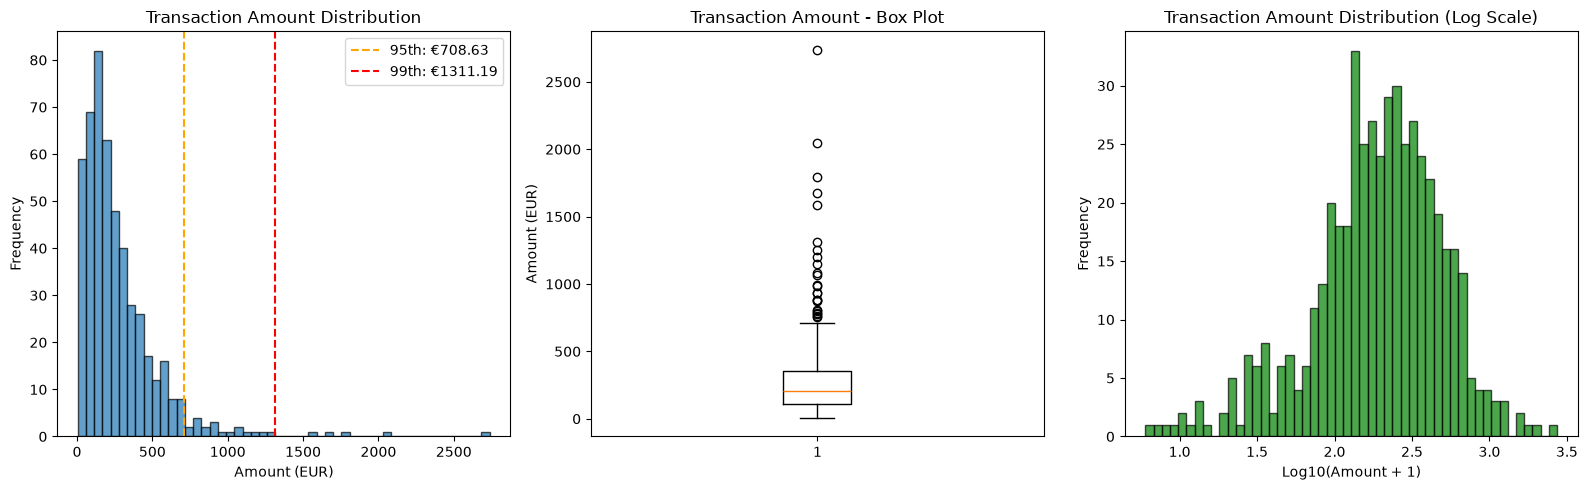

In [29]:
from scipy import stats
print("="*70)
print("TRANSACTION AMOUNT ANALYSIS")
print("="*70)

print("\nTransaction Amount Statistics:")
print(df['transaction_amount_eur'].describe())

# Detect unusually high amounts (e.g., > 95th percentile)
amount_95th = df['transaction_amount_eur'].quantile(0.95)
amount_99th = df['transaction_amount_eur'].quantile(0.99)
high_amount_transactions = df[df['transaction_amount_eur'] > amount_95th]

print(f"\n95th percentile amount: €{amount_95th:.2f}")
print(f"99th percentile amount: €{amount_99th:.2f}")
print(f"Transactions above 95th percentile: {len(high_amount_transactions)}")

# Z-score analysis for outliers (|z| > 2 = outlier, |z| > 3 = extreme)
df['amount_zscore'] = np.abs(stats.zscore(df['transaction_amount_eur']))
outliers_2sigma = df[df['amount_zscore'] > 2]
outliers_3sigma = df[df['amount_zscore'] > 3]

print(f"Outliers (Z-score > 2): {len(outliers_2sigma)} transactions")
print(f"Extreme outliers (Z-score > 3): {len(outliers_3sigma)} transactions")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram with percentiles
axes[0].hist(df['transaction_amount_eur'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(amount_95th, color='orange', linestyle='--', label=f'95th: €{amount_95th:.2f}')
axes[0].axvline(amount_99th, color='red', linestyle='--', label=f'99th: €{amount_99th:.2f}')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
bp = axes[1].boxplot(df['transaction_amount_eur'], vert=True)
axes[1].set_title('Transaction Amount - Box Plot')
axes[1].set_ylabel('Amount (EUR)')

# Log scale for better visibility of distribution
axes[2].hist(np.log10(df['transaction_amount_eur'] + 1), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Transaction Amount Distribution (Log Scale)')
axes[2].set_xlabel('Log10(Amount + 1)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()



TRANSACTION FREQUENCY ANALYSIS

Transactions per Account:
count    147.000000
mean       3.401361
std        1.698750
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       10.000000
dtype: float64

95th percentile: 6 transactions per account
Accounts with high frequency (>95th): 7

Transaction Frequency - Last 24h:
count    500.00000
mean       2.95800
std        1.78623
min        1.00000
25%        1.00000
50%        3.00000
75%        4.00000
max       11.00000
Name: transactions_last_24h, dtype: float64
95th percentile (last 24h): 6 transactions


C:\Users\HP\AppData\Local\Temp\ipykernel_11420\1479621660.py:42: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(df['transactions_last_24h'], vert=True)


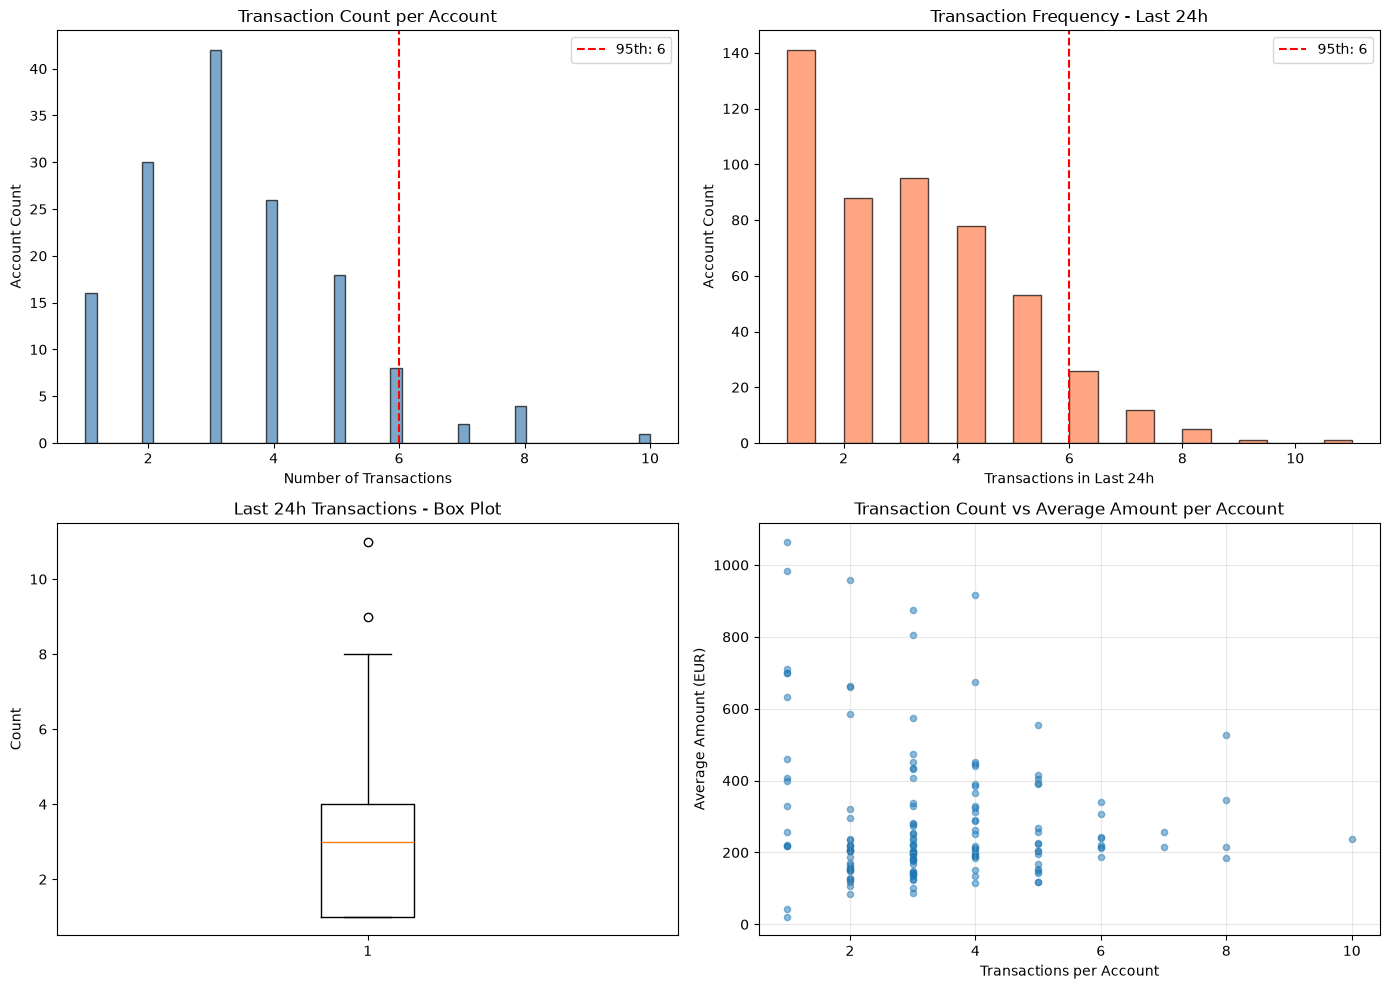

In [39]:
print("\n" + "="*70)
print("TRANSACTION FREQUENCY ANALYSIS")
print("="*70)

# Transactions per account
transactions_per_account = df.groupby('account_id').size()
print("\nTransactions per Account:")
print(transactions_per_account.describe())

freq_95th = transactions_per_account.quantile(0.95)
high_freq_accounts = transactions_per_account[transactions_per_account > freq_95th]
print(f"\n95th percentile: {freq_95th:.0f} transactions per account")
print(f"Accounts with high frequency (>95th): {len(high_freq_accounts)}")

# Last 24h transaction frequency
print("\nTransaction Frequency - Last 24h:")
print(df['transactions_last_24h'].describe())

freq_24h_95th = df['transactions_last_24h'].quantile(0.95)
print(f"95th percentile (last 24h): {freq_24h_95th:.0f} transactions")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Transactions per account histogram
axes[0, 0].hist(transactions_per_account, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(freq_95th, color='red', linestyle='--', label=f'95th: {freq_95th:.0f}')
axes[0, 0].set_title('Transaction Count per Account')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_ylabel('Account Count')
axes[0, 0].legend()

# Last 24h frequency histogram
axes[0, 1].hist(df['transactions_last_24h'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(freq_24h_95th, color='red', linestyle='--', label=f'95th: {freq_24h_95th:.0f}')
axes[0, 1].set_title('Transaction Frequency - Last 24h')
axes[0, 1].set_xlabel('Transactions in Last 24h')
axes[0, 1].set_ylabel('Account Count')
axes[0, 1].legend()

# Box plot for last 24h
axes[1, 0].boxplot(df['transactions_last_24h'], vert=True)
axes[1, 0].set_title('Last 24h Transactions - Box Plot')
axes[1, 0].set_ylabel('Count')

# Scatter: transactions per account vs avg transaction amount
axes[1, 1].scatter(transactions_per_account, df.groupby('account_id')['transaction_amount_eur'].mean(), alpha=0.5, s=20)
axes[1, 1].set_title('Transaction Count vs Average Amount per Account')
axes[1, 1].set_xlabel('Transactions per Account')
axes[1, 1].set_ylabel('Average Amount (EUR)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TRANSACTION TYPE ANALYSIS

Transaction Type Distribution:
                  Count  Percentage
transaction_type                   
Card Purchase       209        41.8
Online Payment      141        28.2
Bank Transfer        97        19.4
Cash Withdrawal      53        10.6

Average Transaction Amount by Type:
                        mean  median         std    min      max
transaction_type                                                
Bank Transfer     256.589278  194.67  266.706678   6.37  2049.23
Card Purchase     282.735933  219.24  272.529540   5.00  1796.49
Cash Withdrawal   249.247170  166.69  263.898367  10.88  1308.39
Online Payment    297.838440  216.42  299.175458   9.44  2738.21


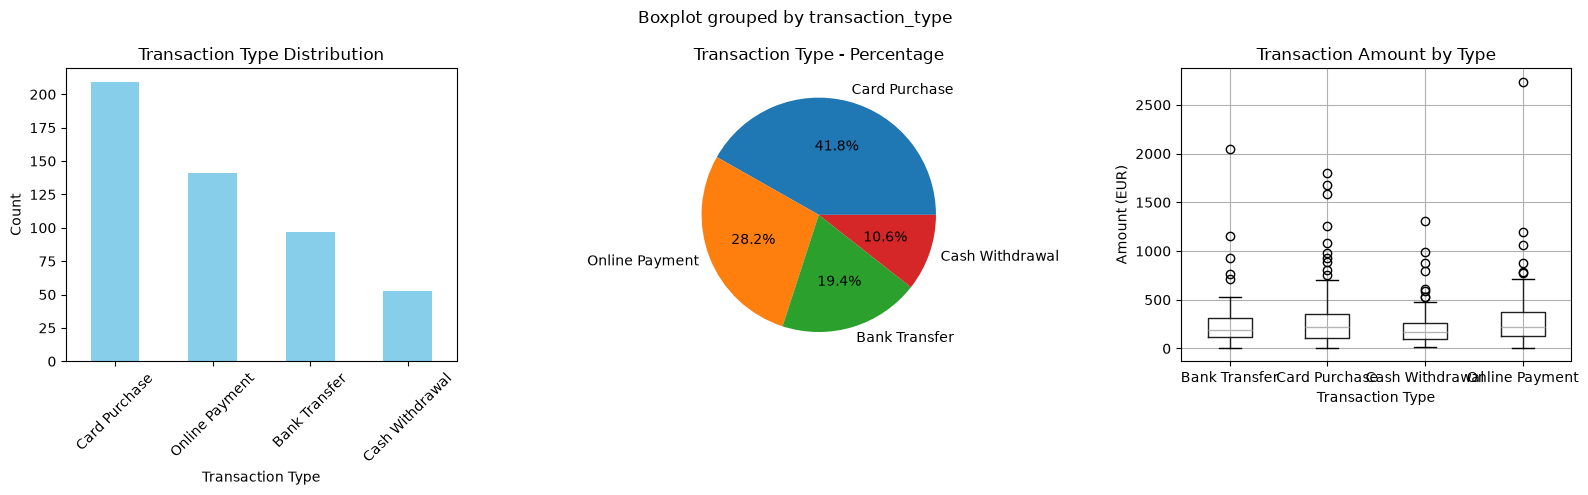

In [35]:

print("\n" + "="*70)
print("TRANSACTION TYPE ANALYSIS")
print("="*70)

type_counts = df['transaction_type'].value_counts()
type_pct = df['transaction_type'].value_counts(normalize=True) * 100

print("\nTransaction Type Distribution:")
type_summary = pd.DataFrame({'Count': type_counts, 'Percentage': type_pct})
print(type_summary)

# Amount by type
print("\nAverage Transaction Amount by Type:")
print(df.groupby('transaction_type')['transaction_amount_eur'].agg(['mean', 'median', 'std', 'min', 'max']))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

type_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Transaction Type Distribution')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

type_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Transaction Type - Percentage')
axes[1].set_ylabel('')

df.boxplot(column='transaction_amount_eur', by='transaction_type', ax=axes[2])
axes[2].set_title('Transaction Amount by Type')
axes[2].set_xlabel('Transaction Type')
axes[2].set_ylabel('Amount (EUR)')

plt.tight_layout()
plt.show()


MERCHANT CATEGORY ANALYSIS

Top 15 Merchant Categories:
merchant_category
Food             76
Financial        76
Travel           75
Services         74
Entertainment    69
Retail           65
Electronics      65
Name: count, dtype: int64

Average Transaction Amount by Category (Top 10):
                   count        mean   median         std
merchant_category                                        
Financial             76  299.618289  215.995  240.545167
Food                  76  293.912500  218.180  288.290861
Travel                75  251.708267  178.080  294.727798
Services              74  302.594865  234.575  362.962863
Entertainment         69  263.932029  177.750  231.194029
Electronics           65  247.469077  194.670  196.773283
Retail                65  284.784769  208.660  296.294521


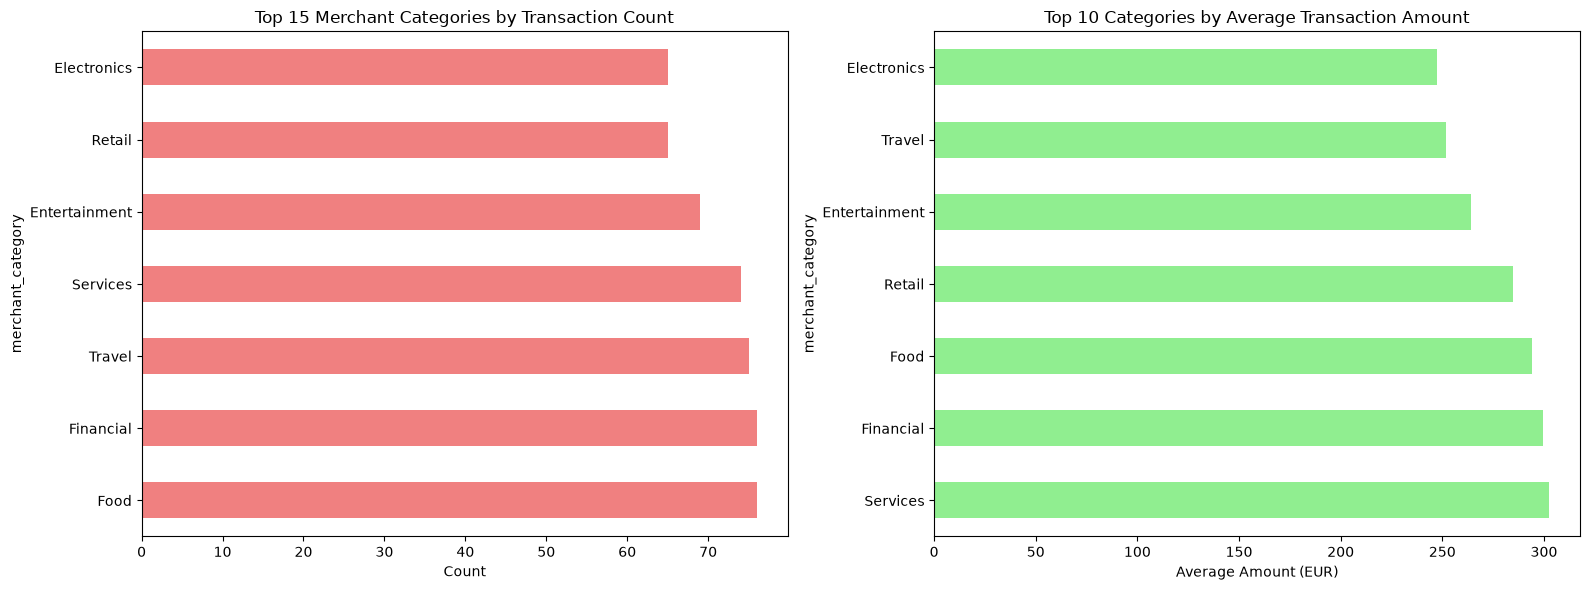

In [36]:
print("\n" + "="*70)
print("MERCHANT CATEGORY ANALYSIS")
print("="*70)

category_counts = df['merchant_category'].value_counts()
print("\nTop 15 Merchant Categories:")
print(category_counts.head(15))

print("\nAverage Transaction Amount by Category (Top 10):")
category_stats = df.groupby('merchant_category')['transaction_amount_eur'].agg(['count', 'mean', 'median', 'std']).sort_values('count', ascending=False)
print(category_stats.head(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

category_counts.head(15).plot(kind='barh', ax=axes[0], color='lightcoral')
axes[0].set_title('Top 15 Merchant Categories by Transaction Count')
axes[0].set_xlabel('Count')

df.groupby('merchant_category')['transaction_amount_eur'].mean().sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 Categories by Average Transaction Amount')
axes[1].set_xlabel('Average Amount (EUR)')

plt.tight_layout()
plt.show()


LOCATION ANALYSIS

Top 15 Locations:
location
Madrid       70
Lisbon       70
Paris        68
Rome         63
Amsterdam    60
Berlin       59
Barcelona    58
Prague       52
Name: count, dtype: int64

Average Transaction Amount by Location (Top 10):
           count        mean   median
location                             
Lisbon        70  264.859571  181.410
Madrid        70  298.194143  209.710
Paris         68  277.072794  196.890
Rome          63  311.769365  223.270
Amsterdam     60  289.375000  218.405
Berlin        59  268.453220  189.020
Barcelona     58  266.819483  185.705
Prague        52  242.564231  217.830


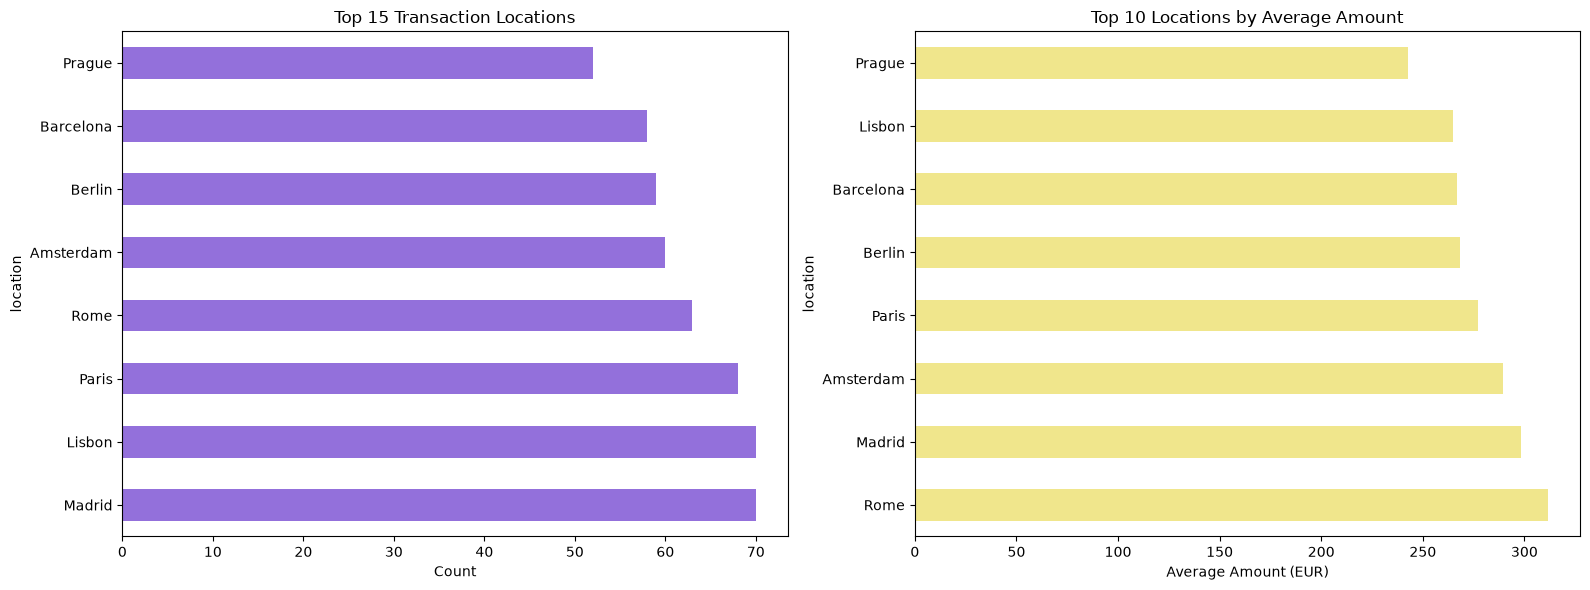

In [37]:
print("\n" + "="*70)
print("LOCATION ANALYSIS")
print("="*70)

location_counts = df['location'].value_counts()
print(f"\nTop 15 Locations:")
print(location_counts.head(15))

print(f"\nAverage Transaction Amount by Location (Top 10):")
location_stats = df.groupby('location')['transaction_amount_eur'].agg(['count', 'mean', 'median']).sort_values('count', ascending=False)
print(location_stats.head(10))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

location_counts.head(15).plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Top 15 Transaction Locations')
axes[0].set_xlabel('Count')

df.groupby('location')['transaction_amount_eur'].mean().sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[1], color='khaki')
axes[1].set_title('Top 10 Locations by Average Amount')
axes[1].set_xlabel('Average Amount (EUR)')

plt.tight_layout()
plt.show()


ACCOUNT CHARACTERISTICS ANALYSIS

Account Age (months):
count    500.000000
mean      72.800000
std       41.025922
min        2.000000
25%       38.750000
50%       72.000000
75%      110.000000
max      144.000000
Name: account_age_months, dtype: float64

Average Account Transaction Amount:
count    500.000000
mean     216.945680
std      101.684424
min       20.000000
25%      149.085000
50%      216.885000
75%      287.630000
max      562.090000
Name: avg_account_transaction_eur, dtype: float64

Correlation Matrix:
                             transaction_amount_eur  account_age_months  \
transaction_amount_eur                     1.000000           -0.041523   
account_age_months                        -0.041523            1.000000   
avg_account_transaction_eur                0.451178            0.041718   
transactions_last_24h                      0.062608           -0.055765   

                             avg_account_transaction_eur  \
transaction_amount_eur                

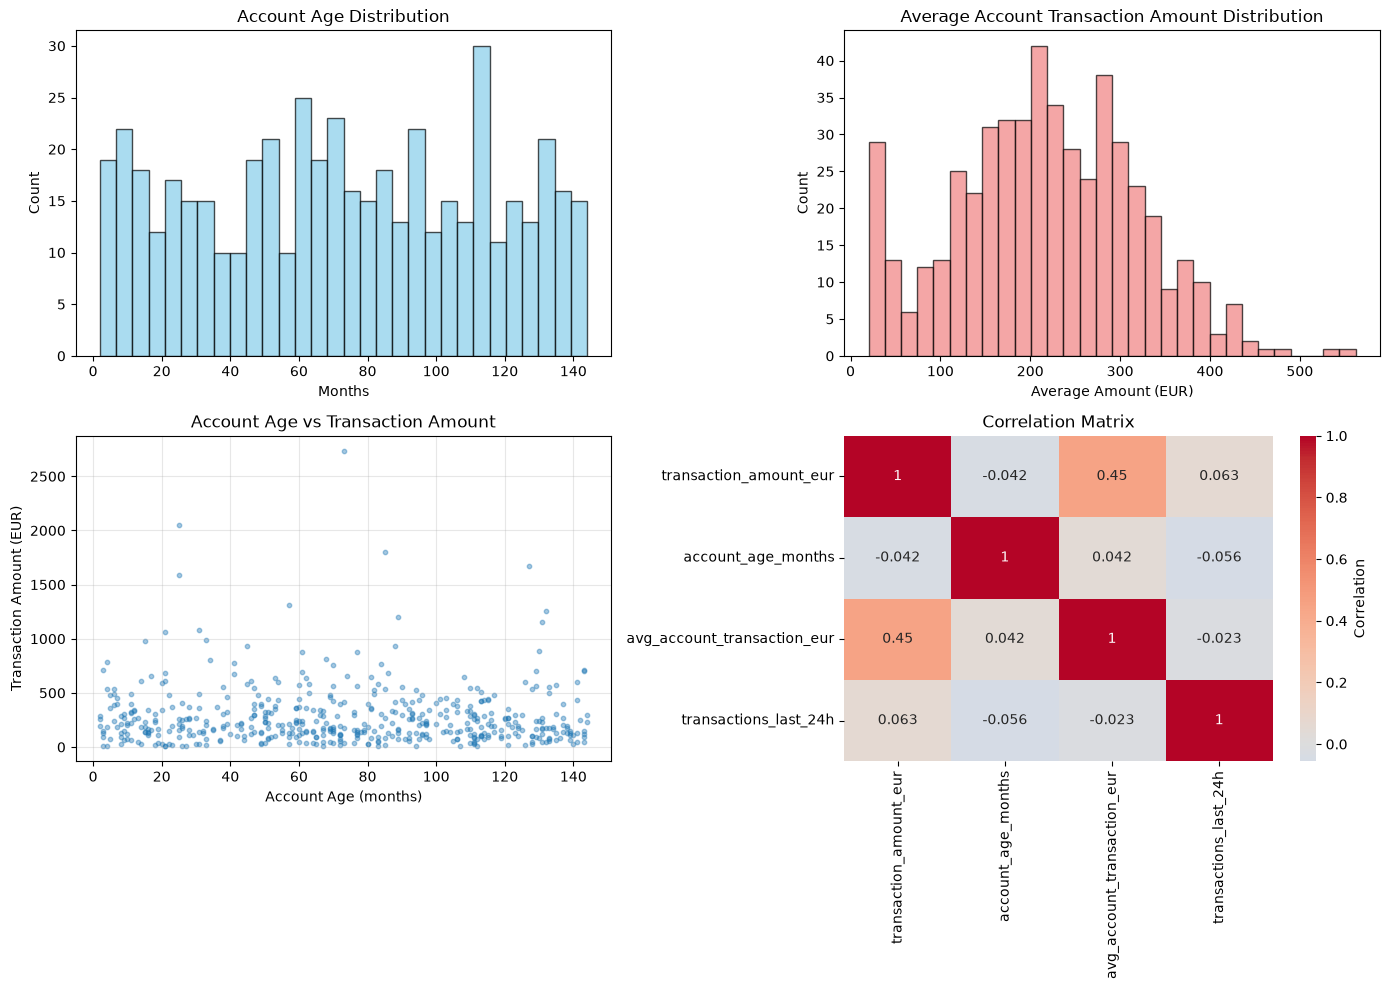

In [38]:
print("\n" + "="*70)
print("ACCOUNT CHARACTERISTICS ANALYSIS")
print("="*70)

print("\nAccount Age (months):")
print(df['account_age_months'].describe())

print("\nAverage Account Transaction Amount:")
print(df['avg_account_transaction_eur'].describe())

# Correlations
account_corr = df[['transaction_amount_eur', 'account_age_months', 'avg_account_transaction_eur', 'transactions_last_24h']].corr()
print("\nCorrelation Matrix:")
print(account_corr)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Account age distribution
axes[0, 0].hist(df['account_age_months'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Account Age Distribution')
axes[0, 0].set_xlabel('Months')
axes[0, 0].set_ylabel('Count')

# Average transaction amount
axes[0, 1].hist(df['avg_account_transaction_eur'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_title('Average Account Transaction Amount Distribution')
axes[0, 1].set_xlabel('Average Amount (EUR)')
axes[0, 1].set_ylabel('Count')

# Scatter: account age vs transaction amount
axes[1, 0].scatter(df['account_age_months'], df['transaction_amount_eur'], alpha=0.4, s=10)
axes[1, 0].set_title('Account Age vs Transaction Amount')
axes[1, 0].set_xlabel('Account Age (months)')
axes[1, 0].set_ylabel('Transaction Amount (EUR)')
axes[1, 0].grid(True, alpha=0.3)

# Heatmap of correlations
sns.heatmap(account_corr, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [40]:
print("\n" + "="*70)
print("UNUSUAL TRANSACTION PATTERNS")
print("="*70)

# High amount transactions
high_amount_threshold = df['transaction_amount_eur'].quantile(0.95)
high_amounts = df[df['transaction_amount_eur'] > high_amount_threshold]
print(f"\nUnusually High Amounts (>95th percentile: €{high_amount_threshold:.2f}):")
print(f"  Count: {len(high_amounts)}")
print(f"  Average: €{high_amounts['transaction_amount_eur'].mean():.2f}")

# High frequency accounts
high_freq_threshold = df['transactions_last_24h'].quantile(0.90)
high_freq = df[df['transactions_last_24h'] > high_freq_threshold]
print(f"\nHigh Transaction Frequency (>90th percentile: {high_freq_threshold:.0f} in 24h):")
print(f"  Count: {len(high_freq)}")
print(f"  Average amount: €{high_freq['transaction_amount_eur'].mean():.2f}")

# New accounts with high activity
new_account_threshold = 6  # months
new_accounts = df[df['account_age_months'] < new_account_threshold]
high_activity_new = new_accounts[new_accounts['transactions_last_24h'] > new_accounts['transactions_last_24h'].quantile(0.75)]
print(f"\nNew Accounts (<{new_account_threshold} months) with High Activity:")
print(f"  Count: {len(high_activity_new)}")
print(f"  Average amount: €{high_activity_new['transaction_amount_eur'].mean():.2f}")

# Unusual patterns: high amount + high frequency
high_amount_high_freq = df[(df['transaction_amount_eur'] > high_amount_threshold) & 
                           (df['transactions_last_24h'] > high_freq_threshold)]
print(f"\nCombined Pattern: High Amount + High Frequency:")
print(f"  Count: {len(high_amount_high_freq)}")
print(f"  Average amount: €{high_amount_high_freq['transaction_amount_eur'].mean():.2f}")


UNUSUAL TRANSACTION PATTERNS

Unusually High Amounts (>95th percentile: €708.63):
  Count: 25
  Average: €1151.04

High Transaction Frequency (>90th percentile: 5 in 24h):
  Count: 45
  Average amount: €373.42

New Accounts (<6 months) with High Activity:
  Count: 1
  Average amount: €93.51

Combined Pattern: High Amount + High Frequency:
  Count: 2
  Average amount: €2163.10


In [41]:
print("="*70)
print("DATA PREPARATION FOR ISOLATION FOREST")
print("="*70)


# Create a copy for modeling
df_model = df[numerical_columns].copy()

print(f"\nFeatures selected for modeling: {numerical_columns}")
print(f"Dataset shape: {df_model.shape}")
print(f"\nFeature statistics:")
print(df_model.describe())

DATA PREPARATION FOR ISOLATION FOREST

Features selected for modeling: ['transaction_amount_eur', 'transactions_last_24h', 'avg_account_transaction_eur', 'account_age_months']
Dataset shape: (500, 4)

Feature statistics:
       transaction_amount_eur  transactions_last_24h  \
count              500.000000              500.00000   
mean               278.372580                2.95800   
std                278.047854                1.78623   
min                  5.000000                1.00000   
25%                111.300000                1.00000   
50%                204.320000                3.00000   
75%                354.907500                4.00000   
max               2738.210000               11.00000   

       avg_account_transaction_eur  account_age_months  
count                   500.000000          500.000000  
mean                    216.945680           72.800000  
std                     101.684424           41.025922  
min                      20.000000            

In [43]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')
print("\n" + "="*70)
print("FEATURE STANDARDIZATION")
print("="*70)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
df_scaled = pd.DataFrame(df_scaled, columns=numerical_columns, index=df_model.index)

print(f"\nScaled feature statistics (mean ~0, std ~1):")
print(df_scaled.describe())


FEATURE STANDARDIZATION

Scaled feature statistics (mean ~0, std ~1):
       transaction_amount_eur  transactions_last_24h  \
count            5.000000e+02           5.000000e+02   
mean             9.947598e-17          -7.105427e-17   
std              1.001002e+00           1.001002e+00   
min             -9.841700e-01          -1.097261e+00   
25%             -6.014789e-01          -1.097261e+00   
50%             -2.665971e-01           2.353676e-02   
75%              2.755338e-01           5.839358e-01   
max              8.855673e+00           4.506729e+00   

       avg_account_transaction_eur  account_age_months  
count                 5.000000e+02        5.000000e+02  
mean                  1.882938e-16        7.105427e-17  
std                   1.001002e+00        1.001002e+00  
min                  -1.938772e+00       -1.727467e+00  
25%                  -6.680339e-01       -8.307943e-01  
50%                  -5.973459e-04       -1.951940e-02  
75%                   6.9

In [44]:
print("\n" + "="*70)
print("ISOLATION FOREST MODEL TRAINING")
print("="*70)

# contamination parameter = expected proportion of anomalies
contamination_rate = 0.05  # Assume 5% of transactions are anomalies

iso_forest = IsolationForest(
    contamination=contamination_rate,
    random_state=42,
    n_estimators=100,
    max_samples='auto'
)

# Fit and predict (-1 = anomaly, 1 = normal)
anomaly_predictions = iso_forest.fit_predict(df_scaled)
anomaly_scores = iso_forest.score_samples(df_scaled)  # Lower scores = more anomalous

# Add predictions to dataframe
df['anomaly_label'] = anomaly_predictions
df['anomaly_score'] = anomaly_scores

# Count anomalies
n_anomalies = (anomaly_predictions == -1).sum()
n_normal = (anomaly_predictions == 1).sum()

print(f"\nIsolation Forest Results:")
print(f"  Normal transactions: {n_normal} ({n_normal/len(df)*100:.2f}%)")
print(f"  Anomalous transactions: {n_anomalies} ({n_anomalies/len(df)*100:.2f}%)")
print(f"  Contamination rate: {contamination_rate*100:.2f}%")

print(f"\nAnomaly Score Statistics:")
print(f"  Mean: {anomaly_scores.mean():.4f}")
print(f"  Std: {anomaly_scores.std():.4f}")
print(f"  Min: {anomaly_scores.min():.4f}")
print(f"  Max: {anomaly_scores.max():.4f}")


ISOLATION FOREST MODEL TRAINING

Isolation Forest Results:
  Normal transactions: 475 (95.00%)
  Anomalous transactions: 25 (5.00%)
  Contamination rate: 5.00%

Anomaly Score Statistics:
  Mean: -0.4717
  Std: 0.0475
  Min: -0.7446
  Max: -0.4068


In [45]:
print("\n" + "="*70)
print("ANOMALY CHARACTERISTICS")
print("="*70)

anomalies = df[df['anomaly_label'] == -1]
normal = df[df['anomaly_label'] == 1]

print(f"\nAnomalous Transactions - Feature Comparison:")
print("\nAnomalies:")
print(anomalies[numerical_columns].describe())
print("\nNormal Transactions:")
print(normal[numerical_columns].describe())

# Compare means
print(f"\nMean Comparison (Anomalies vs Normal):")
comparison = pd.DataFrame({
    'Anomalies Mean': anomalies[numerical_columns].mean(),
    'Normal Mean': normal[numerical_columns].mean(),
    'Difference': anomalies[numerical_columns].mean() - normal[numerical_columns].mean(),
    'Ratio (Anomaly/Normal)': anomalies[numerical_columns].mean() / normal[numerical_columns].mean()
})
print(comparison)

# Sample of detected anomalies
print(f"\nSample of 10 Detected Anomalies:")
print(anomalies[numerical_columns + ['anomaly_score']].nlargest(10, 'anomaly_score'))



ANOMALY CHARACTERISTICS

Anomalous Transactions - Feature Comparison:

Anomalies:
       transaction_amount_eur  transactions_last_24h  \
count               25.000000              25.000000   
mean               855.846800               4.480000   
std                691.501916               3.229035   
min                  6.370000               1.000000   
25%                307.970000               1.000000   
50%                605.730000               3.000000   
75%               1150.040000               8.000000   
max               2738.210000              11.000000   

       avg_account_transaction_eur  account_age_months  
count                    25.000000           25.000000  
mean                    311.049200           73.080000  
std                     142.405239           48.314008  
min                      20.000000           13.000000  
25%                     268.680000           25.000000  
50%                     326.130000           73.000000  
75%          

In [46]:
print("\n" + "="*70)
print("ISOLATION FOREST vs FRAUD STATUS COMPARISON")
print("="*70)

# Convert fraud_status to binary (assuming 'fraud' = 1, else = 0)
df['is_fraud'] = (df['fraud_status'] == 'Fraud').astype(int)

# Convert anomaly labels to binary (anomaly = 1, normal = 0)
df['is_anomaly'] = (df['anomaly_label'] == -1).astype(int)

print(f"\nFraud Distribution in Dataset:")
fraud_counts = df['is_fraud'].value_counts()
print(f"  Legitimate: {fraud_counts[0]} ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"  Fraudulent: {fraud_counts[1]} ({fraud_counts[1]/len(df)*100:.2f}%)")

# Confusion Matrix
print(f"\nConfusion Matrix:")
cm = confusion_matrix(df['is_fraud'], df['is_anomaly'])
print(cm)
print(f"  True Negatives (TN):  {cm[0,0]} - Correctly identified as normal")
print(f"  False Positives (FP): {cm[0,1]} - Normal transactions flagged as anomalies")
print(f"  False Negatives (FN): {cm[1,0]} - Fraudulent transactions missed")
print(f"  True Positives (TP):  {cm[1,1]} - Correctly identified as fraud")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(df['is_fraud'], df['is_anomaly'], 
                           target_names=['Legitimate', 'Fraud']))

# Metrics
accuracy = accuracy_score(df['is_fraud'], df['is_anomaly'])
precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
f1 = f1_score(df['is_fraud'], df['is_anomaly'])

print(f"\nKey Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f} (of flagged anomalies, how many are fraud?)")
print(f"  Recall:    {recall:.4f} (of all fraud, how many are caught?)")
print(f"  F1-Score:  {f1:.4f}")

# ROC-AUC Score
try:
    roc_auc = roc_auc_score(df['is_fraud'], df['is_anomaly'])
    print(f"  ROC-AUC:   {roc_auc:.4f}")
except:
    print(f"  ROC-AUC:   Cannot compute (possibly only one class)")


ISOLATION FOREST vs FRAUD STATUS COMPARISON

Fraud Distribution in Dataset:
  Legitimate: 490 (98.00%)
  Fraudulent: 10 (2.00%)

Confusion Matrix:
[[469  21]
 [  6   4]]
  True Negatives (TN):  469 - Correctly identified as normal
  False Positives (FP): 21 - Normal transactions flagged as anomalies
  False Negatives (FN): 6 - Fraudulent transactions missed
  True Positives (TP):  4 - Correctly identified as fraud

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.96      0.97       490
       Fraud       0.16      0.40      0.23        10

    accuracy                           0.95       500
   macro avg       0.57      0.68      0.60       500
weighted avg       0.97      0.95      0.96       500


Key Metrics:
  Accuracy:  0.9460
  Precision: 0.1600 (of flagged anomalies, how many are fraud?)
  Recall:    0.4000 (of all fraud, how many are caught?)
  F1-Score:  0.2286
  ROC-AUC:   0.6786


In [47]:
print("\n" + "="*70)
print("CROSS-TABULATION: ANOMALIES vs FRAUD")
print("="*70)

cross_tab = pd.crosstab(df['is_fraud'], df['is_anomaly'], 
                        rownames=['Fraud Status'], 
                        colnames=['Anomaly Detection'],
                        margins=True)
cross_tab.columns = ['Normal (Model)', 'Anomaly (Model)', 'Total']
cross_tab.index = ['Legitimate', 'Fraudulent', 'Total']

print(f"\n{cross_tab}")

# Calculate detection rate
fraud_detected_rate = cm[1,1] / fraud_counts[1] * 100
print(f"\nFraud Detection Rate: {fraud_detected_rate:.2f}% of fraudulent transactions detected")

# Calculate false positive rate
if fraud_counts[0] > 0:
    fp_rate = cm[0,1] / fraud_counts[0] * 100
    print(f"False Positive Rate: {fp_rate:.2f}% of legitimate transactions flagged as anomalies")



CROSS-TABULATION: ANOMALIES vs FRAUD

            Normal (Model)  Anomaly (Model)  Total
Legitimate             469               21    490
Fraudulent               6                4     10
Total                  475               25    500

Fraud Detection Rate: 40.00% of fraudulent transactions detected
False Positive Rate: 4.29% of legitimate transactions flagged as anomalies


In [48]:

print("\n" + "="*70)
print("ANOMALY SCORE ANALYSIS")
print("="*70)

print(f"\nAnomalies by Fraud Status:")
anomaly_fraud_cross = pd.crosstab(df['is_anomaly'], df['is_fraud'], margins=True)
print(anomaly_fraud_cross)

# Average anomaly score by fraud status
print(f"\nAverage Anomaly Score by Fraud Status:")
score_by_fraud = df.groupby('is_fraud')['anomaly_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
score_by_fraud.index = ['Legitimate', 'Fraudulent']
print(score_by_fraud)

# Average anomaly score by detection
print(f"\nAverage Anomaly Score by Detection:")
score_by_detection = df.groupby('is_anomaly')['anomaly_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
score_by_detection.index = ['Normal (Model)', 'Anomaly (Model)']
print(score_by_detection)


ANOMALY SCORE ANALYSIS

Anomalies by Fraud Status:
is_fraud      0   1  All
is_anomaly              
0           469   6  475
1            21   4   25
All         490  10  500

Average Anomaly Score by Fraud Status:
            count      mean    median       std       min       max
Legitimate    490 -0.469988 -0.458532  0.043939 -0.661128 -0.406839
Fraudulent     10 -0.555328 -0.508923  0.112287 -0.744555 -0.438004

Average Anomaly Score by Detection:
                 count      mean    median       std       min       max
Normal (Model)     475 -0.464921 -0.455135  0.036472 -0.554341 -0.406839
Anomaly (Model)     25 -0.600389 -0.574731  0.051052 -0.744555 -0.557791
